# Análisis Exploratorio de Datos (EDA) – Análisis univariado

## Objetivo

Realizar un análisis descriptivo del conjunto de datos preparado para el modelado con el fin de evaluar su calidad, conocer la distribución de las variables principales y detectar posibles anomalías antes de las fases de modelado y análisis avanzado.

In [2]:
import polars as pl
import matplotlib.pyplot as plt

### Paso 1. Carga del conjunto de datos

Se carga el conjunto de datos consolidado en formato Parquet utilizando Polars.

#### Decisión tomada

Se utiliza el formato Parquet por su eficiencia en almacenamiento y lectura, especialmente adecuado para conjuntos de datos con millones de registros.

In [3]:
df = pl.read_parquet("../data/modeling/base_modelado.parquet")

### Paso 2. Inspección inicial

Se realiza una revisión preliminar del conjunto de datos observando:

- primeras filas
- número de registros
- número de variables
- tipo de dato de cada columna

#### Objetivo

Comprobar que el conjunto de datos se ha cargado correctamente y que las variables presentan el formato esperado.

#### Decisión tomada

Antes de iniciar cualquier análisis descriptivo se verifica la estructura del conjunto de datos para evitar errores derivados de tipos incorrectos o problemas de importación.

In [4]:
df.head()

id_sensor,id_fecha,hora,intensidad_media,intensidad_max,intensidad_min,ocupacion_media,ocupacion_max,velocidad_media,velocidad_min,num_mediciones,num_error_E,porcentaje_calidad,año,mes,nombre_mes,trimestre,dia,dia_semana,fin_semana,tipo_elem,distrito,latitud,longitud
i32,date,i32,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,i64,i64,str,i64,i64,i64,bool,str,i32,f64,f64
5082,2026-06-06,21,815.25,866.0,765.0,5.25,6.0,0.0,0.0,4,0.0,100.0,2026,6,"""June""",2,6,6,true,"""URB""",4,40.424951,-3.67879
5082,2026-06-14,23,403.5,488.0,313.0,2.0,3.0,0.0,0.0,4,0.0,100.0,2026,6,"""June""",2,14,0,true,"""URB""",4,40.424951,-3.67879
6849,2026-06-01,5,87.0,120.0,48.0,0.25,1.0,54.0,36.0,4,0.0,100.0,2026,6,"""June""",2,1,1,false,"""other""",2,40.400236,-3.716322
6849,2026-06-06,19,1284.0,1704.0,1008.0,6.25,9.0,58.5,55.0,4,0.0,100.0,2026,6,"""June""",2,6,6,true,"""other""",2,40.400236,-3.716322
6849,2026-06-07,0,726.0,852.0,528.0,3.5,4.0,62.5,61.0,4,0.0,100.0,2026,6,"""June""",2,7,0,true,"""other""",2,40.400236,-3.716322


In [5]:
print(f"Filas: {df.height}")
print(f"Columnas: {df.width}")

Filas: 40521392
Columnas: 24


In [6]:
df.schema

Schema([('id_sensor', Int32),
        ('id_fecha', Date),
        ('hora', Int32),
        ('intensidad_media', Float64),
        ('intensidad_max', Float64),
        ('intensidad_min', Float64),
        ('ocupacion_media', Float64),
        ('ocupacion_max', Float64),
        ('velocidad_media', Float64),
        ('velocidad_min', Float64),
        ('num_mediciones', Int64),
        ('num_error_E', Float64),
        ('porcentaje_calidad', Float64),
        ('año', Int64),
        ('mes', Int64),
        ('nombre_mes', String),
        ('trimestre', Int64),
        ('dia', Int64),
        ('dia_semana', Int64),
        ('fin_semana', Boolean),
        ('tipo_elem', String),
        ('distrito', Int32),
        ('latitud', Float64),
        ('longitud', Float64)])

### Paso 3. Comprobación de valores nulos

Se contabilizan los valores ausentes de todas las variables.

#### Objetivo

Evaluar la calidad del conjunto de datos y detectar posibles pérdidas de información.

#### Decisión tomada

No se realizan imputaciones durante esta fase. El objetivo es únicamente diagnosticar si existen problemas de calidad que requieran tratamiento posterior.

In [7]:
(
    df.null_count()
      .transpose(
          include_header=True,
          header_name="columna",
          column_names=["nulos"]
      )
      .sort("nulos", descending=True)
)

columna,nulos
str,u32
"""id_sensor""",0
"""id_fecha""",0
"""hora""",0
"""intensidad_media""",0
"""intensidad_max""",0
…,…
"""fin_semana""",0
"""tipo_elem""",0
"""distrito""",0


### Paso 4. Comprobación de registros duplicados

Se calcula el número de combinaciones únicas utilizando las variables identificadoras:

- id_sensor
- id_fecha
- hora

#### Objetivo

Verificar que cada observación representa una única medición de tráfico.

#### Decisión tomada

La ausencia de duplicados confirma que el proceso de integración y preparación de datos ha mantenido la integridad del conjunto de datos.

In [8]:
total_registros = df.height

registros_unicos = (
    df.select(
        [
            "id_sensor",
            "id_fecha",
            "hora"
        ]
    )
    .unique()
    .height
)

print(f"Registros totales: {total_registros}")
print(f"Registros únicos: {registros_unicos}")
print(
    f"Duplicados: {total_registros - registros_unicos}"
)

Registros totales: 40521392
Registros únicos: 40521392
Duplicados: 0


### Paso 5. Distribución de registros por tipo de sensor

Se agrupan los registros según el tipo de sensor.

Posteriormente se representa gráficamente el número de observaciones de cada categoría.

#### Objetivo

Conocer la composición del conjunto de datos y el peso relativo de cada tipo de sensor.

#### Decisión tomada

Se analiza esta variable porque diferentes tipos de sensores pueden presentar comportamientos de tráfico distintos y requerir análisis separados.

In [9]:
tipo = (
    df.group_by("tipo_elem")
      .agg(pl.len().alias("registros"))
      .sort("registros", descending=True)
)

tipo

tipo_elem,registros
str,u32
"""URB""",36939419
"""M30""",2595362
"""other""",986611


### Paso 6. Visualización de la distribución por tipo

Se construye un gráfico de barras con el número de registros correspondiente a cada tipo de sensor.

#### Objetivo

Facilitar la comparación visual entre categorías.

#### Resultados observados

Se aprecia un claro predominio de los sensores urbanos (URB), seguidos por los sensores de la M30 y, finalmente, por los sensores clasificados como other.

#### Decisión tomada

Dado el importante desequilibrio entre categorías, el análisis descriptivo posterior se realiza de forma independiente para cada tipo de sensor.

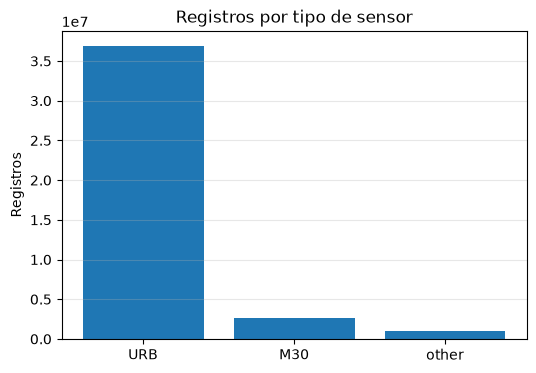

In [10]:
tipo_pd = tipo.to_pandas()

plt.figure(figsize=(6,4))

plt.bar(
    tipo_pd["tipo_elem"],
    tipo_pd["registros"]
)

plt.title("Registros por tipo de sensor")
plt.ylabel("Registros")

plt.grid(axis="y",alpha=.3)

plt.show()

La mayor parte de los registros corresponden a sensores URB (más de 36,9 millones), seguidos por M30 (2,6 millones) y other (casi 1 millón). Esta diferencia justifica analizar cada tipo de sensor por separado, ya que representan infraestructuras con características y comportamientos distintos.

### Paso 7. Análisis univariado por tipo de sensor

Se define una función que realiza automáticamente el análisis descriptivo para cada categoría de sensor.

Entre otros aspectos, analiza:

- número de sensores
- número de registros
- distribución de la intensidad
- principales estadísticos descriptivos

#### Objetivo

Comparar el comportamiento de las distintas infraestructuras de medida.

#### Decisión tomada

Automatizar el procedimiento garantiza que todos los tipos de sensores sean analizados mediante exactamente los mismos criterios.

In [11]:
def eda_tipo(df, tipo):

    print("="*60)
    print(f"ANÁLISIS {tipo}")
    print("="*60)

    datos = df.filter(
        pl.col("tipo_elem")==tipo
    )

    print(f"Registros: {datos.height:,}")
    print(f"Sensores: {datos['id_sensor'].n_unique()}")

    display(
        datos.select([
            "intensidad_media",
            "ocupacion_media",
            "velocidad_media"
        ]).describe()
    )

    muestra = datos.sample(
        n=min(100000, datos.height),
        seed=42
    )

    # ------------------------
    # Intensidad
    # ------------------------

    intensidad = muestra.filter(
        pl.col("intensidad_media") < 3000
    )["intensidad_media"].to_pandas()

    plt.figure(figsize=(8,4))

    intensidad.hist(
        bins=50,
        color="#4E79A7",
        edgecolor="white"
    )

    plt.title(f"Distribución de intensidad media ({tipo})")

    plt.xlabel("Vehículos")

    plt.ylabel("Frecuencia")

    plt.grid(alpha=.3)

    plt.tight_layout()

    plt.show()


    plt.figure(figsize=(8,2.5))

    plt.boxplot(
        intensidad,
        orientation="horizontal",
        patch_artist=True,
        boxprops=dict(facecolor="#4E79A7")
    )

    plt.title(f"Boxplot intensidad media ({tipo})")

    plt.tight_layout()

    plt.show()

    # ------------------------
    # Ocupación
    # ------------------------

    ocupacion = muestra["ocupacion_media"].to_pandas()

    plt.figure(figsize=(8,4))

    ocupacion.hist(
        bins=40,
        color="#59A14F",
        edgecolor="white"
    )

    plt.title(f"Distribución de ocupación media ({tipo})")

    plt.xlabel("%")

    plt.ylabel("Frecuencia")

    plt.grid(alpha=.3)

    plt.tight_layout()

    plt.show()


    plt.figure(figsize=(8,2.5))

    plt.boxplot(
        ocupacion,
        orientation="horizontal",
        patch_artist=True,
        boxprops=dict(facecolor="#59A14F")
    )

    plt.title(f"Boxplot ocupación media ({tipo})")

    plt.tight_layout()

    plt.show()


    # ------------------------
    # Velocidad
    # ------------------------

    if muestra["velocidad_media"].max() > 0:

        velocidad = muestra["velocidad_media"].to_pandas()

        plt.figure(figsize=(8,4))

        velocidad.hist(
            bins=40,
            color="#F28E2B",
            edgecolor="white"
        )

        plt.title(f"Distribución de velocidad media ({tipo})")

        plt.xlabel("km/h")

        plt.ylabel("Frecuencia")

        plt.grid(alpha=.3)

        plt.tight_layout()

        plt.show()


        plt.figure(figsize=(8,2.5))

        plt.boxplot(
            velocidad,
            orientation="horizontal",
            patch_artist=True,
            boxprops=dict(facecolor="#F28E2B")
        )

        plt.title(f"Boxplot velocidad media ({tipo})")

        plt.tight_layout()

        plt.show()

    else:

        print("Este tipo de sensor no registra velocidad.")

### Paso 8. Aplicación del análisis a cada categoría

La función anterior se ejecuta para:

- URB
- M30
- other

#### Objetivo

Obtener una caracterización independiente de cada grupo de sensores.

#### Decisión tomada

Analizar las categorías por separado evita que la distribución dominante de los sensores urbanos oculte el comportamiento de los demás grupos.

ANÁLISIS URB
Registros: 36,939,419
Sensores: 4473


statistic,intensidad_media,ocupacion_media,velocidad_media
str,f64,f64,f64
"""count""",3.6939419e7,3.6939419e7,3.6939419e7
"""null_count""",0.0,0.0,0.0
"""mean""",259.655232,5.142388,0.0
"""std""",385.352631,8.990623,0.0
"""min""",0.0,0.0,0.0
"""25%""",45.25,0.5,0.0
"""50%""",138.0,2.25,0.0
"""75%""",338.0,5.5,0.0
"""max""",91368.333333,100.0,0.0


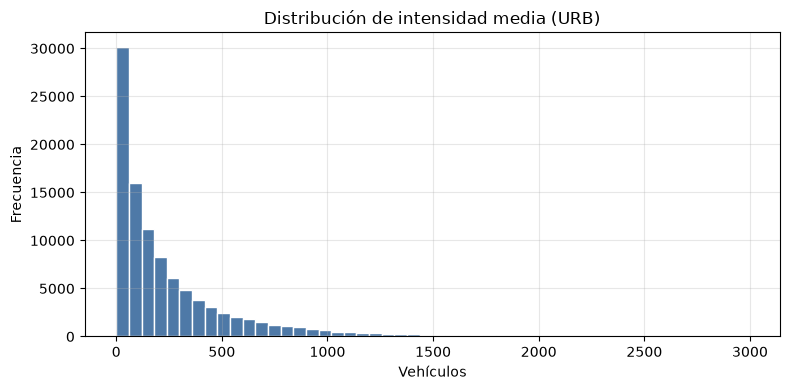

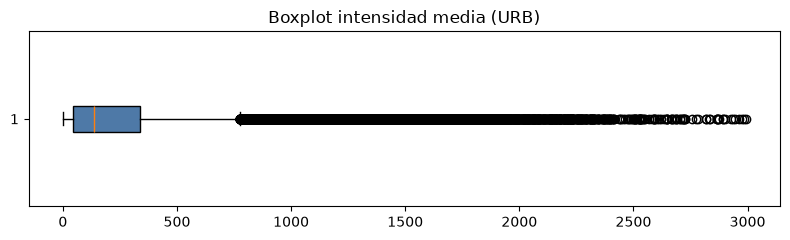

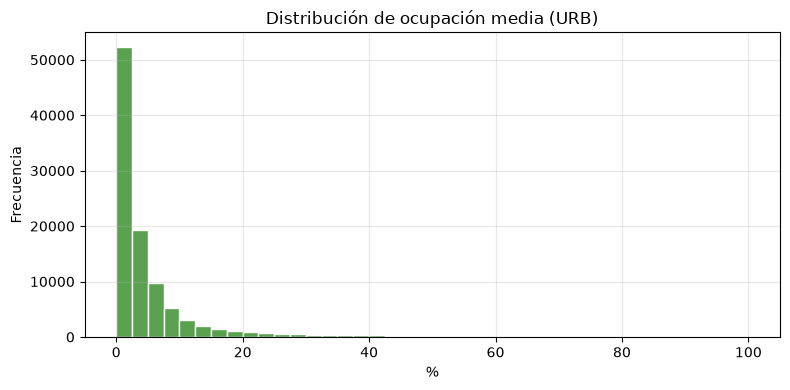

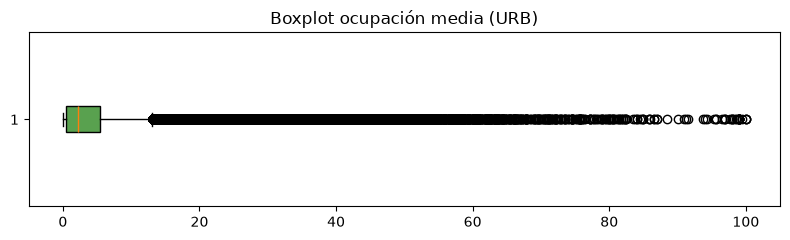

Este tipo de sensor no registra velocidad.
ANÁLISIS M30
Registros: 2,595,362
Sensores: 313


statistic,intensidad_media,ocupacion_media,velocidad_media
str,f64,f64,f64
"""count""",2.595362e6,2.595362e6,2.595362e6
"""null_count""",0.0,0.0,0.0
"""mean""",1194.768451,5.566194,63.528722
"""std""",1274.52447,7.608905,25.611738
"""min""",0.0,0.0,0.0
"""25%""",216.75,0.75,53.0
"""50%""",733.25,3.5,70.25
"""75%""",1788.0,7.5,81.75
"""max""",7666.25,100.0,246.0


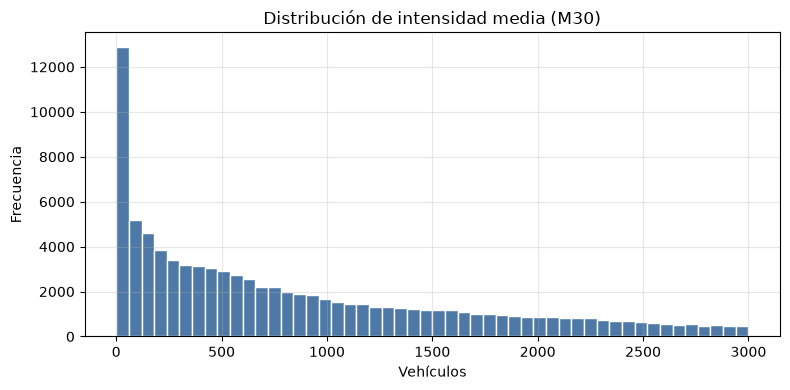

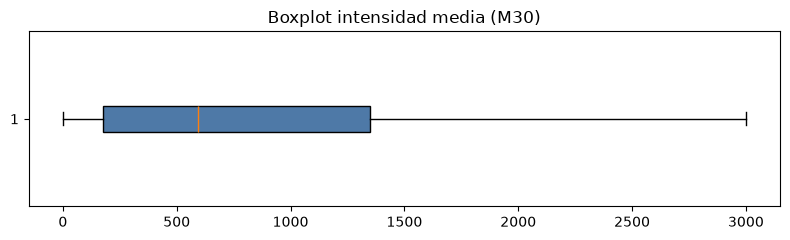

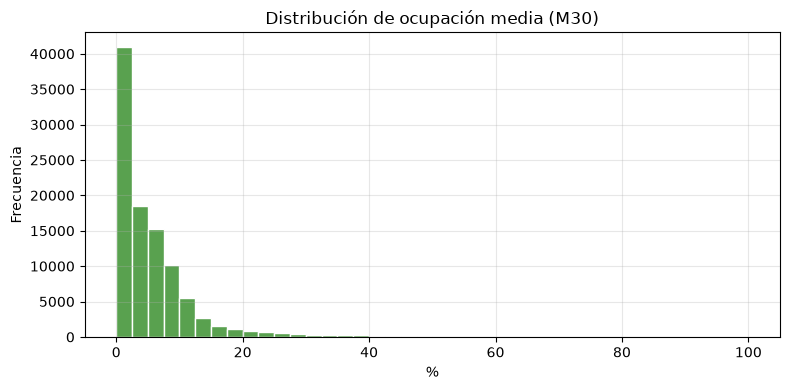

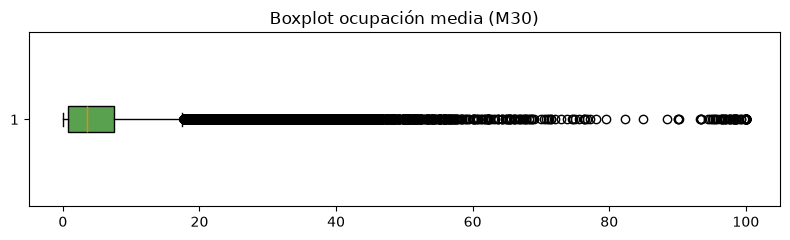

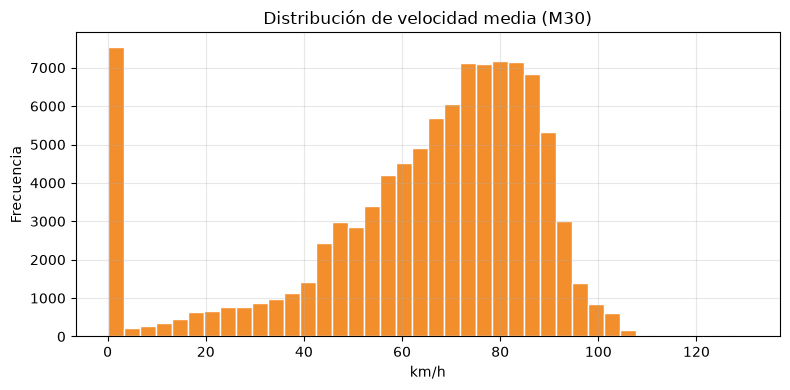

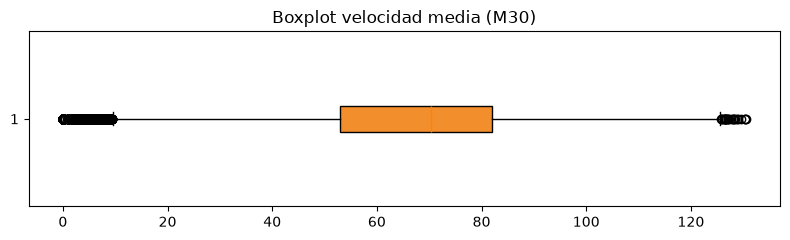

ANÁLISIS other
Registros: 986,611
Sensores: 147


statistic,intensidad_media,ocupacion_media,velocidad_media
str,f64,f64,f64
"""count""",986611.0,986611.0,986611.0
"""null_count""",0.0,0.0,0.0
"""mean""",863.694201,7.887604,43.03545
"""std""",1166.912816,19.524076,28.449479
"""min""",0.0,0.0,0.0
"""25%""",18.0,0.0,11.75
"""50%""",354.0,2.25,53.25
"""75%""",1220.0,6.25,64.75
"""max""",8415.0,100.0,159.75


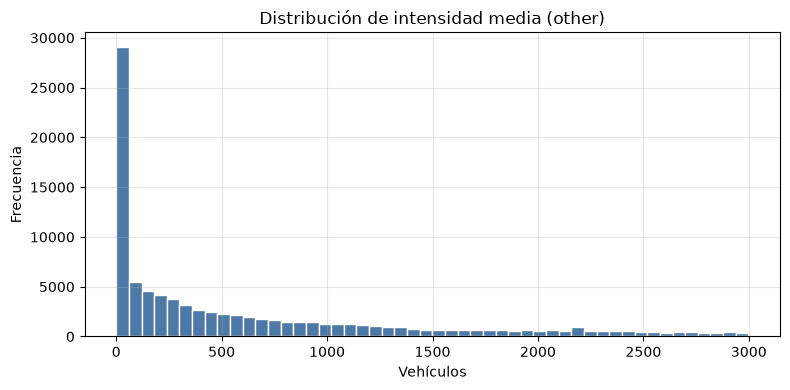

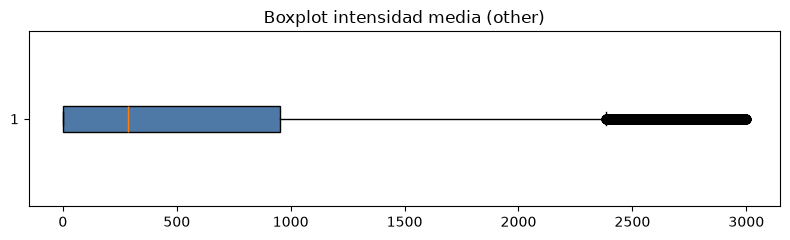

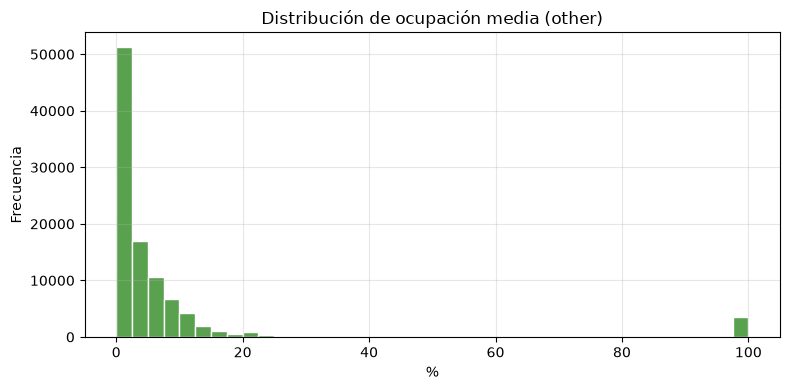

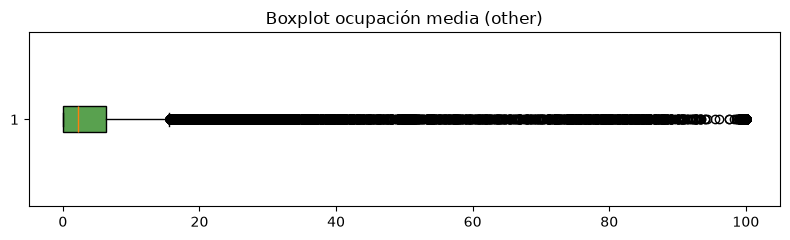

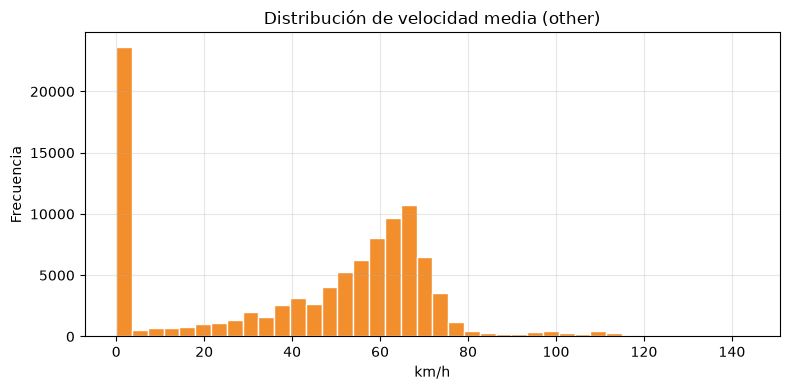

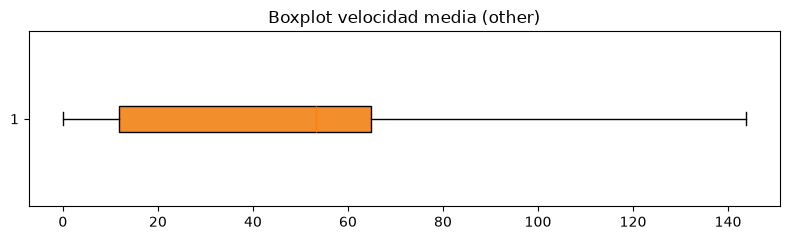

In [12]:
for tipo in ["URB","M30","other"]:

    eda_tipo(df,tipo)

### Paso 9. Interpretación de los resultados por tipo

### Sensores URB

#### Resultados

Los sensores urbanos concentran la mayor parte del conjunto de datos (36,9 millones de registros y 4.473 sensores).

La distribución de la intensidad presenta una elevada variabilidad, reflejando la diversidad del tráfico existente en la red urbana.

#### Decisión tomada

Estos sensores constituyen el núcleo principal del conjunto de datos y serán especialmente relevantes en los análisis posteriores.

### Sensores M30

#### Resultados

Los sensores de la M30 muestran una distribución más homogénea de la intensidad, coherente con el comportamiento del tráfico en una vía de circunvalación.

#### Decisión tomada

Se mantiene este grupo diferenciado debido a sus características propias respecto al tráfico urbano convencional.

### Sensores other

#### Resultados

Este grupo reúne un número considerablemente menor de sensores y registros.

La distribución de intensidades presenta mayor dispersión debido a la heterogeneidad de las vías incluidas.

#### Decisión tomada

Aunque representa una proporción menor del conjunto de datos, se conserva para mantener la representatividad de toda la red de sensores.

### Paso 10. Análisis de la calidad de las mediciones

Se calculan los principales estadísticos descriptivos de la variable que mide la calidad de cada observación.

#### Objetivo

Evaluar la fiabilidad de las mediciones registradas.

#### Decisión tomada

La calidad de las mediciones constituye un indicador fundamental para garantizar la validez de los análisis posteriores.

In [13]:
df["porcentaje_calidad"].describe()

statistic,value
str,f64
"""count""",4.0521392e7
"""null_count""",0.0
"""mean""",99.517551
"""std""",6.845825
"""min""",0.0
"""25%""",100.0
"""50%""",100.0
"""75%""",100.0
"""max""",100.0


### Paso 11. Distribución del porcentaje de calidad

Se representa un histograma del porcentaje de calidad utilizando una muestra aleatoria del conjunto de datos.

#### Objetivo

Visualizar la distribución de la calidad sin necesidad de representar los millones de registros disponibles.

#### Decisión tomada

Se utiliza una muestra aleatoria suficientemente grande para reducir el coste computacional manteniendo una representación fiel de la distribución.

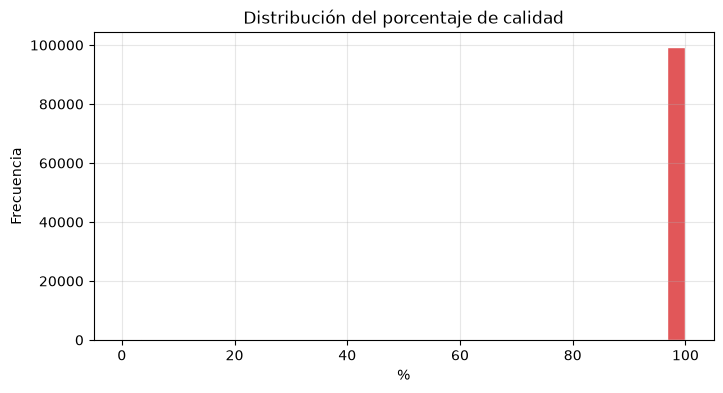

In [14]:
plt.figure(figsize=(8,4))

df.sample(
    100000,
    seed=42
)["porcentaje_calidad"].to_pandas().hist(
    bins=30,
    color="#E15759",
    edgecolor="white"
)

plt.title("Distribución del porcentaje de calidad")

plt.xlabel("%")

plt.ylabel("Frecuencia")

plt.grid(alpha=.3)

plt.show()

### Paso 12. Interpretación de la calidad de los datos

#### Resultados

El porcentaje de calidad presenta valores muy elevados en prácticamente todas las observaciones.

La mayoría de los registros alcanzan una calidad cercana al 100 %, indicando un funcionamiento adecuado de la red de sensores.

#### Decisión tomada

No se considera necesario aplicar filtros adicionales basados en esta variable, ya que no se detectan problemas relevantes de calidad.

### Paso 13. Conclusiones del análisis univariado

#### Resultados principales

El conjunto de datos no presenta problemas relevantes de valores nulos.
No se detectan duplicados tras el proceso de preparación.
Existe un claro predominio de sensores urbanos respecto al resto de categorías.
Cada tipo de sensor presenta características propias en la distribución de la intensidad del tráfico.
La calidad de las mediciones es muy elevada en prácticamente todo el conjunto de datos.

#### Decisión metodológica

El análisis confirma que el conjunto de datos presenta un nivel de calidad suficiente para continuar con las siguientes fases del proyecto, sin necesidad de aplicar procedimientos adicionales de limpieza antes del análisis bivariado y del desarrollo de modelos predictivos.